Why split data into train, validation and text?

So, if model just memorizing the data and not generalizing we will able to check with validation and test data. Simple!

Earlier we divided data in only two: training and test. This violate blind test rule and not good for production, can cause overfitting.

As we traine netwrok and using test dataset for validation. We are aiming to optimize our model for the test data only. In prod, this model might fail.

Solution: Train and tune model with training and validation data => test at last on test data.

In [17]:
import numpy as np
import struct
import matplotlib.pyplot as plt


In [4]:
def load_images(filename):
    with open(filename,'rb') as f:
        _,n_images,columns,rows = struct.unpack('>IIII',f.read(16))

        all_pixels = np.frombuffer(f.read(),dtype=np.uint8)

        return all_pixels.reshape(n_images,columns*rows)


def load_labels(filename):

    with open(filename,'rb') as f:
        f.read(8)
        all_labels = f.read()
        return np.frombuffer(all_labels,dtype=np.uint8).reshape(-1,1)


def one_hot_encode(Y):
    n_examples = Y.shape[0]
    n_classes = np.unique(Y).size

    encoded_Y = np.zeros((n_examples,n_classes))

    for i in range(n_examples):
        label = Y[i]
        encoded_Y[i][label] = 1
    return encoded_Y

In [6]:
#Let's split the data now => split test data into validation and test: 5k,5k

X_train = load_images("Datasets/archive/train-images-idx3-ubyte/train-images-idx3-ubyte")
X_test_all = load_images("Datasets/archive/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte")
X_validation,X_test = np.split(X_test_all,2)

Y_train_unencoded = load_labels("Datasets/archive/train-labels-idx1-ubyte/train-labels-idx1-ubyte")
Y_train = one_hot_encode(Y_train_unencoded)

Y_test_all = load_labels("Datasets/archive/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte")
Y_validation,Y_test = np.split(Y_test_all,2)


In [9]:
print("Training features and Training Labels shape: " + str(X_train.shape) + str(Y_train.shape))
print("Validation features and Validation Labels shape: " + str(X_validation.shape) + str(Y_validation.shape))
print("Test features and Test Labels shape: " + str(X_test.shape) + str(Y_test.shape))




Training features and Training Labels shape: (60000, 784)(60000, 10)
Validation features and Validation Labels shape: (5000, 784)(5000, 1)
Test features and Test Labels shape: (5000, 784)(5000, 1)


hyperparameter tuning, model selection is guided by the validation set: we try different algorithms and pick the one that gives us the best validation accuracy. That fact only makes the validation set even more important, and it doesn’t just help us tune hyperparameters. It also guides us toward the right algorithm.

In [12]:
#The Neural Network

import numpy as np


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def softmax(logits):
    exponentials = np.exp(logits)
    return exponentials / np.sum(exponentials, axis=1).reshape(-1, 1)


def sigmoid_gradient(sigmoid):
    return np.multiply(sigmoid, (1 - sigmoid))


def prepend_bias(X):
    return np.insert(X, 0, 1, axis=1)


def forward(X, w1, w2):
    h = sigmoid(np.matmul(prepend_bias(X), w1))
    y_hat = softmax(np.matmul(prepend_bias(h), w2))
    return (y_hat, h)


def back(X, Y, y_hat, w2, h):
    w2_gradient = np.matmul(prepend_bias(h).T, (y_hat - Y)) / X.shape[0]
    w1_gradient = np.matmul(prepend_bias(X).T,
                            np.matmul(y_hat - Y, w2[1:].T) *
                            sigmoid_gradient(h)) / X.shape[0]
    return (w1_gradient, w2_gradient)


def classify(X, w1, w2):
    y_hat, _ = forward(X, w1, w2)
    labels = np.argmax(y_hat, axis=1)
    return labels.reshape(-1, 1)


def accuracy(X, Y_unencoded, w1, w2):
    return np.average(classify(X, w1, w2) == Y_unencoded) * 100.0


def initialize_weights(n_input_variables, n_hidden_nodes, n_classes):
    np.random.seed(1234)

    w1_rows = n_input_variables + 1
    w1 = np.random.randn(w1_rows, n_hidden_nodes) * np.sqrt(1 / w1_rows)

    w2_rows = n_hidden_nodes + 1
    w2 = np.random.randn(w2_rows, n_classes) * np.sqrt(1 / w2_rows)

    return (w1, w2)


# This loss() takes different parameters than the ones in other source files
def loss(X, Y, w1, w2):
    y_hat, _ = forward(X, w1, w2)
    return -np.sum(Y * np.log(y_hat)) / Y.shape[0]


# This train() stores the loss on both the training and the test sets at each
# step. A the end, it returns those histories to the caller.
# Different from train() functions in other source files, it expects that
# _both_ Y_train and Y_test are one hot encoded.
def train(X_train, Y_train, X_test, Y_test, n_hidden_nodes, iterations, lr):
    n_input_variables = X_train.shape[1]
    n_classes = Y_train.shape[1]
    w1, w2 = initialize_weights(n_input_variables, n_hidden_nodes, n_classes)
    training_losses = []
    test_losses = []
    for i in range(iterations):
        y_hat_train, h = forward(X_train, w1, w2)
        y_hat_test, _ = forward(X_test, w1, w2)
        w1_gradient, w2_gradient = back(X_train, Y_train, y_hat_train, w2, h)
        w1 = w1 - (w1_gradient * lr)
        w2 = w2 - (w2_gradient * lr)

        training_loss = -np.sum(Y_train * np.log(y_hat_train)) / \
            Y_train.shape[0]
        training_losses.append(training_loss)
        test_loss = -np.sum(Y_test * np.log(y_hat_test)) / Y_test.shape[0]
        test_losses.append(test_loss)
        print("%5d > Training loss: %.5f - Validation loss: %.5f" %
              (i, training_loss, test_loss))
    return (training_losses, test_losses, w1, w2)

In [ ]:
training_losses,validation_loss,w1,w2 = train(X_train,Y_train,X_validation,
                                        one_hot_encode(Y_validation),
                                        n_hidden_nodes=200,
                                        iterations=100,lr=0.01)





    0 > Training loss: 2.43321 - Validation loss: 2.41634
    1 > Training loss: 2.38746 - Validation loss: 2.37152
    2 > Training loss: 2.34527 - Validation loss: 2.33086
    3 > Training loss: 2.30606 - Validation loss: 2.29310
    4 > Training loss: 2.26964 - Validation loss: 2.25782
    5 > Training loss: 2.23536 - Validation loss: 2.22523
    6 > Training loss: 2.20260 - Validation loss: 2.19439
    7 > Training loss: 2.17130 - Validation loss: 2.16517
    8 > Training loss: 2.14180 - Validation loss: 2.13760
    9 > Training loss: 2.11374 - Validation loss: 2.11111
   10 > Training loss: 2.08688 - Validation loss: 2.08565
   11 > Training loss: 2.06089 - Validation loss: 2.06173
   12 > Training loss: 2.03576 - Validation loss: 2.03872
   13 > Training loss: 2.01171 - Validation loss: 2.01630
   14 > Training loss: 1.98840 - Validation loss: 1.99475
   15 > Training loss: 1.96598 - Validation loss: 1.97416
   16 > Training loss: 1.94439 - Validation loss: 1.95415
   17 > Traini

In [16]:
training_accuracy = accuracy(X_train,Y_train_unencoded,w1,w2)

test_accuracy = accuracy(X_test,Y_test,w1,w2)

print("Training Accuracy is: " + str(training_accuracy))
print("Test Accuracy is:" + str(test_accuracy))

Training Accuracy is: 78.59
Test Accuracy is:83.86


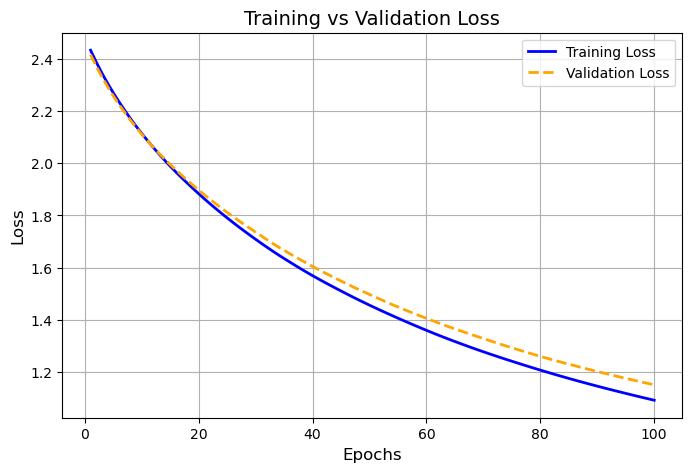

In [19]:
epochs = np.arange(1,101)

plt.figure(figsize=(8,5))
plt.plot(epochs,training_losses,label="Training Loss",color='blue',linewidth=2)
plt.plot(epochs,validation_loss,label="Validation Loss",color='orange',linewidth=2,linestyle='--')

plt.xlabel("Epochs",fontsize=12)
plt.ylabel("Loss",fontsize=12)
plt.title("Training vs Validation Loss",fontsize=14)
plt.legend()
plt.grid(True)
plt.show()


we should take care that the distribution of the examples is the same across the following four sets of data:
The training set
The validation set
The test set
The actual data that the system classifies in production.

While the production data can be challenging to deal with, there is an easy fix to make it more likely that the first three sets have a similar distribution: shuffle the data before you split it into training, validation, and test set.